In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium import plugins

In [77]:
PATH = "../data/raw/planilha_de_area_atingida_por_fogo_historico_dgeo_2025.xlsx"

# ler todas as abas
abas = pd.read_excel(PATH, sheet_name=None)

# salvar cada aba como CSV
for nome_aba, df in abas.items():
    if int(nome_aba) >= int(2020):
        df.to_csv(f"../data/raw/unidades_conservacao_{nome_aba}.csv", index=False)


In [86]:
def limpar_colunas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace('\n', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
    )
    return df

In [87]:
def padronizar_colunas(df):
    mapa = {
        'Unidades de Conservação': 'Unidade de Conservação',
        'Fogo Natural (ha)': 'Fogo natural (ha)',
        'Incêndios (ha)': 'Incêndio (ha)',
        'Área total (ha)': 'Área TOTAL (ha)',
        '% da UC': '% de AAF na UC'
    }
    df = df.rename(columns=mapa)
    return df

In [142]:
PATH = "../data/raw/planilha_de_area_atingida_por_fogo_historico_dgeo_2025.xlsx"

# ler todas as abas
abas = pd.read_excel(PATH, sheet_name=None)

lista_anos = []

for nome_aba, df in abas.items():
    if int(nome_aba) >= int(2020):
        df['Ano'] = int(nome_aba)
        df = limpar_colunas(df)
        df = padronizar_colunas(df)
        lista_anos.append(df)

dataset_reservas = pd.concat(lista_anos, ignore_index=True)

dataset_reservas.columns = dataset_reservas.columns.str.strip()

dataset_reservas = dataset_reservas.drop([
    'Aceiro (ha)',
    'Gestão de ignição natural (ha)', 
    'Gestão de ignição antrópica (ha)', 
    'Queima prescrita (ha)', 
    'Queima controlada (ha)',
    'Indígenas isolados (ha)', 
    'TOTAL MANEJO (ha)',
    'Fogo natural (ha)', 
    'Total Prevenção (ha)', 
    'Total Combate (ha)',
    'Área TOTAL (ha)', 
    'Queima indigena (ha)', 
    'Raios (ha)', 'Bioma',
    'Queima por Indígenas Isolados (ha)',
    'Queima Controlada (ha)',
    'Queima Prescrita (ha)', 
    'Gestão de Raio (ha)', 'Aceiro Negro (ha)',
    'Área Queimada (ha)', 
    'Data Última Atualização', 
    'Satélite',
    'MIF (ha)',
    'NGI',
    'TOTAL INCÊNDIO (ha)',
    'TOTAL (ha)',
    'GR' 
], axis=1)

dataset_reservas.head()

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.6640,1.06,2025
1,APA da Bacia do Rio Descoberto,1055.103906,36159.7695,2.94,2025
2,APA da Baleia Franca,197.210303,154868.3750,0.13,2025
3,APA da Região Serrana de Petrópolis,9.090404,48942.5312,0.02,2025
4,APA da Serra da Mantiqueira,366.208104,419483.4060,0.09,2025


In [143]:
dataset_reservas.head()

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.6640,1.06,2025
1,APA da Bacia do Rio Descoberto,1055.103906,36159.7695,2.94,2025
2,APA da Baleia Franca,197.210303,154868.3750,0.13,2025
3,APA da Região Serrana de Petrópolis,9.090404,48942.5312,0.02,2025
4,APA da Serra da Mantiqueira,366.208104,419483.4060,0.09,2025


In [144]:
dataset_reservas.tail()

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
532,REBIO Nascentes da Serra do Cachimbo,-,342195.772904,7.576573,2020
533,RESEX de Recanto das Araras de Terra Ronca,-,12349.329807,11.037990,2020
534,RESEX do Lago do Capana Grande,-,304313.441018,0.168191,2020
535,RVS das Veredas do Oeste Baiano,16927.749548,128050.552604,14.165635,2020
536,TOTAL,661950.323921,NaN,NaN,2020


In [145]:
dataset_reservas.shape

(537, 5)

reservas localizadas em MG:

APA Cavernas do Peruaçu → MG

APA da Serra da Mantiqueira → MG (também pega SP/RJ, mas inclui MG)

APA Morro da Pedreira → MG

PARNA da Serra da Canastra → MG

PARNA da Serra do Cipó → MG

PARNA da Serra do Gandarela → MG

PARNA das Sempre-Vivas → MG

PARNA de Itatiaia → MG/RJ (parte em MG)

PARNA Grande Sertão Veredas → MG/BA (parte em MG)

RDS Nascentes Geraizeiras → MG

REBIO da Mata Escura → MG

In [147]:
dataset_reservas_mg = dataset_reservas[dataset_reservas['Unidade de Conservação'].str.contains(
    'APA Cavernas do Peruaçu|APA da Serra da Mantiqueira|APA Morro da Pedreira|PARNA da Serra da Canastra|PARNA da Serra do Cipó|PARNA da Serra do Gandarela|PARNA das Sempre-Vivas|PARNA de Itatiaia|PARNA Grande Sertão Veredas|RDS Nascentes Geraizeiras|REBIO da Mata Escura'
)]

dataset_reservas_mg.head(300)

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.664000,1.060000,2025
4,APA da Serra da Mantiqueira,366.208104,419483.406000,0.090000,2025
11,APA Morro da Pedreira,2031.867131,100130.625000,2.320000,2025
36,PARNA da Serra da Canastra,20985.593067,197970.703000,24.060000,2025
39,PARNA da Serra do Cipó,6.144874,31639.277300,9.270000,2025
40,PARNA da Serra do Gandarela,1522.700222,31270.605500,6.650000,2025
45,PARNA das Sempre-Vivas,2129.011131,126616.438000,1.810000,2025
50,PARNA de Itatiaia,38.944827,28085.847700,0.140000,2025
61,PARNA Grande Sertão Veredas,12764.053595,230853.281000,7.910000,2025
64,RDS Nascentes Geraizeiras,211.563123,38177.003900,0.550000,2025


In [150]:
dataset_reservas_mg = dataset_reservas_mg.replace(['-'], np.nan)

dataset_reservas_mg = dataset_reservas_mg.dropna()

dataset_reservas_mg.head(400)

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.664000,1.060000,2025
4,APA da Serra da Mantiqueira,366.208104,419483.406000,0.090000,2025
11,APA Morro da Pedreira,2031.867131,100130.625000,2.320000,2025
36,PARNA da Serra da Canastra,20985.593067,197970.703000,24.060000,2025
39,PARNA da Serra do Cipó,6.144874,31639.277300,9.270000,2025
40,PARNA da Serra do Gandarela,1522.700222,31270.605500,6.650000,2025
45,PARNA das Sempre-Vivas,2129.011131,126616.438000,1.810000,2025
50,PARNA de Itatiaia,38.944827,28085.847700,0.140000,2025
61,PARNA Grande Sertão Veredas,12764.053595,230853.281000,7.910000,2025
64,RDS Nascentes Geraizeiras,211.563123,38177.003900,0.550000,2025


In [ ]:
dataset_reservas_mg.to_csv('../data/processed/data_reservas_2020_2025.csv', sep = ',')



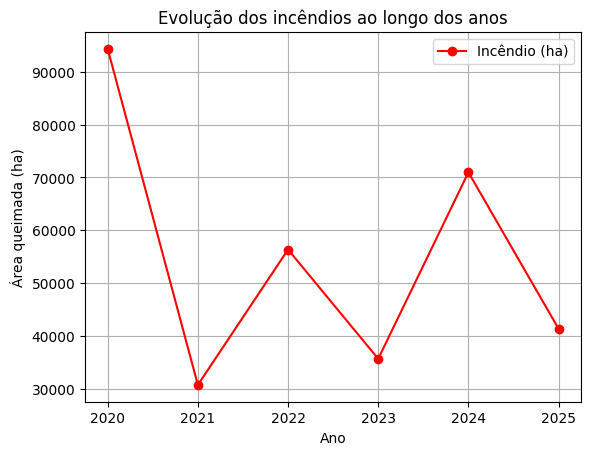

In [168]:
df_ano = dataset_reservas_mg.groupby('Ano')['Incêndio (ha)'].sum()


plt.Figure(figsize=(16, 9))
df_ano.plot(marker='o', color='red')
plt.title("Evolução dos incêndios ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Área queimada (ha)")
plt.grid()
plt.legend()
plt.show()

In [ ]:
ranking_afetados = pd.DataFrame(dataset_reservas_mg.groupby('Unidade de Conservação')['Incêndio (ha)'].sum().sort_values(ascending=False))
ranking_afetados.head(10)

,Incêndio (ha)
Unidade de Conservação,
PARNA da Serra da Canastra,230535.333360
PARNA Grande Sertão Veredas,24404.612453
PARNA da Serra do Cipó,19731.014586
APA Morro da Pedreira,17658.671482
PARNA das Sempre-Vivas,15272.311418
PARNA da Serra do Gandarela,7621.627549
APA da Serra da Mantiqueira,6629.067082
REBIO da Mata Escura,3938.338757
APA Cavernas do Peruaçu,2827.940787


In [159]:
ranking_afetados = pd.DataFrame(dataset_reservas_mg.groupby('Unidade de Conservação')['Incêndio (ha)'].sum().sort_values(ascending=False))
ranking_afetados.head(10)

,Incêndio (ha)
Unidade de Conservação,
PARNA da Serra da Canastra,230535.333360
PARNA Grande Sertão Veredas,24404.612453
PARNA da Serra do Cipó,19731.014586
APA Morro da Pedreira,17658.671482
PARNA das Sempre-Vivas,15272.311418
PARNA da Serra do Gandarela,7621.627549
APA da Serra da Mantiqueira,6629.067082
REBIO da Mata Escura,3938.338757
APA Cavernas do Peruaçu,2827.940787


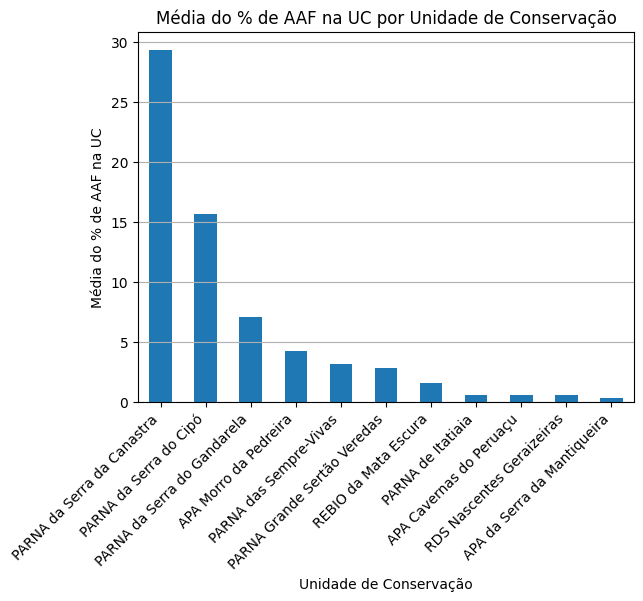

In [167]:
df_reservas = dataset_reservas_mg.groupby('Unidade de Conservação')['% de AAF na UC'].mean().sort_values(ascending=False)

plt.Figure(figsize=(16, 9))
df_reservas.plot(kind='bar')
plt.title("Média do % de AAF na UC por Unidade de Conservação")
plt.xlabel("Unidade de Conservação")
plt.ylabel("Média do % de AAF na UC")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()